In [ ]:
import pandas as pd
import numpy as np
import os
import sys

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_validate
from sklearn.model_selection import StratifiedKFold

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    balanced_accuracy_score
)

"""
En caso de que Python no encuentre en la ruta los otros directorios,
ejecutar esta configuración
"""

sys.path.append(os.path.abspath(".."))

In [2]:
data_train = pd.read_csv("../../../dataset/Spotify_train_preprocesado_clasificacion.csv")

data_test = pd.read_csv("../../../dataset/Spotify_test_preprocesado_clasificacion.csv")

df_train = data_train.copy()
df_test = data_test.copy()

print("Dataset de entrenamiento: ")
display(df_train.head())


print("Dataset de pruebas: ")
display(df_test.head())

Dataset de entrenamiento: 


,bin__track_genre_0,bin__track_genre_1,bin__track_genre_2,bin__track_genre_3,bin__track_genre_4,bin__track_genre_5,bin__track_genre_6,ord__duration_category,num__danceability,num__energy,...,num__loudness,num__mode,num__speechiness,num__acousticness,num__instrumentalness,num__liveness,num__valence,num__tempo,num__duration_min,popularity_category
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.360656,0.407609,0.005418,...,-0.557598,0.751125,-0.804229,0.532848,-0.562123,-0.436477,1.542740,-0.147610,-0.695300,1
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.360656,0.100464,-0.034422,...,-0.017461,0.751125,-0.785413,0.623235,-0.606882,-0.678120,1.183864,0.437714,-0.191994,0
2,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.927115,-1.881489,0.216573,...,0.430609,0.751125,-0.519639,-0.618079,-0.580263,-0.985860,-1.305115,0.437984,0.625209,2
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.360656,1.746296,0.336094,...,0.571210,-1.331337,-0.500823,-0.710274,-0.606882,-0.635477,-0.506326,0.064335,-0.879964,0
4,0.0,0.0,0.0,0.0,1.0,0.0,1.0,-0.360656,0.726344,-1.795371,...,-2.390784,-1.331337,1.124396,1.430692,1.793755,-0.671013,1.195440,2.664353,-0.772929,2


Dataset de pruebas: 


,bin__track_genre_0,bin__track_genre_1,bin__track_genre_2,bin__track_genre_3,bin__track_genre_4,bin__track_genre_5,bin__track_genre_6,ord__duration_category,num__danceability,num__energy,...,num__loudness,num__mode,num__speechiness,num__acousticness,num__instrumentalness,num__liveness,num__valence,num__tempo,num__duration_min,popularity_category
0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.927115,-1.452645,-1.914892,...,-2.318107,0.751125,-0.700742,1.813330,1.793755,-0.700153,-1.619613,-0.133029,1.330330,0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.360656,1.798453,0.626930,...,1.478109,0.751125,0.865678,-0.675324,-0.606764,1.390062,1.450127,-0.406397,-0.528812,0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.360656,0.639416,0.224541,...,0.842404,0.751125,-0.199770,-0.940037,-0.606785,-0.724317,1.303489,2.353574,-0.550148,0
3,1.0,0.0,0.0,0.0,1.0,1.0,0.0,-1.648427,-0.067596,0.754419,...,0.438615,0.751125,2.126046,1.707878,-0.606882,2.409939,0.292462,-1.350621,-1.566635,1
4,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.927115,0.830657,1.093063,...,1.257701,0.751125,-0.380872,-0.942719,1.793755,-1.048403,1.006355,0.096426,1.158399,0


In [3]:
# Separación de variables predictoras y objetivo
X_train = df_train.drop(
    columns=["popularity_category"]
)

y_train = df_train[
    "popularity_category"
]

X_test = df_test.drop(
    columns=["popularity_category"]
)

y_test = df_test[
    "popularity_category"
]

# Testeo de KNN con K = 3 y 5

In [8]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision_weighted": "precision_weighted",
    "recall_weighted": "recall_weighted",
    "f1_weighted": "f1_weighted",
    "f1_macro": "f1_macro"
}

resultados_knn = {}

for k in [3, 5]:

    print(f"\nIniciando validación cruzada para K={k}...", flush=True)

    knn_model = KNeighborsClassifier(
        n_neighbors=k,
        weights="uniform",
        metric="euclidean",
        n_jobs=1
    )

    scores_knn = cross_validate(
        knn_model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    resultados_knn[k] = {
        "promedios": {
            metrica: scores_knn[f"test_{metrica}"].mean()
            for metrica in scoring
        },
        "desviaciones": {
            metrica: scores_knn[f"test_{metrica}"].std()
            for metrica in scoring
        }
    }

    print(f"\nResultados de KNN (K={k}):")

    for metrica, valor in resultados_knn[k]["promedios"].items():
        print(f"{metrica}: {valor:.4f}")

    print("\nDesviación estándar entre particiones:")

    for metrica, valor in resultados_knn[k]["desviaciones"].items():
        print(f"{metrica}: {valor:.4f}")

    print(f"\nValidación de K={k} finalizada.", flush=True)


Iniciando validación cruzada para K=3...

Resultados de KNN (K=3):
accuracy: 0.6920
balanced_accuracy: 0.6920
precision_weighted: 0.6841
recall_weighted: 0.6920
f1_weighted: 0.6818
f1_macro: 0.6818

Desviación estándar entre particiones:
accuracy: 0.0017
balanced_accuracy: 0.0017
precision_weighted: 0.0017
recall_weighted: 0.0017
f1_weighted: 0.0018
f1_macro: 0.0018

Validación de K=3 finalizada.

Iniciando validación cruzada para K=5...

Resultados de KNN (K=5):
accuracy: 0.6792
balanced_accuracy: 0.6792
precision_weighted: 0.6693
recall_weighted: 0.6792
f1_weighted: 0.6690
f1_macro: 0.6690

Desviación estándar entre particiones:
accuracy: 0.0024
balanced_accuracy: 0.0024
precision_weighted: 0.0027
recall_weighted: 0.0024
f1_weighted: 0.0024
f1_macro: 0.0024

Validación de K=5 finalizada.


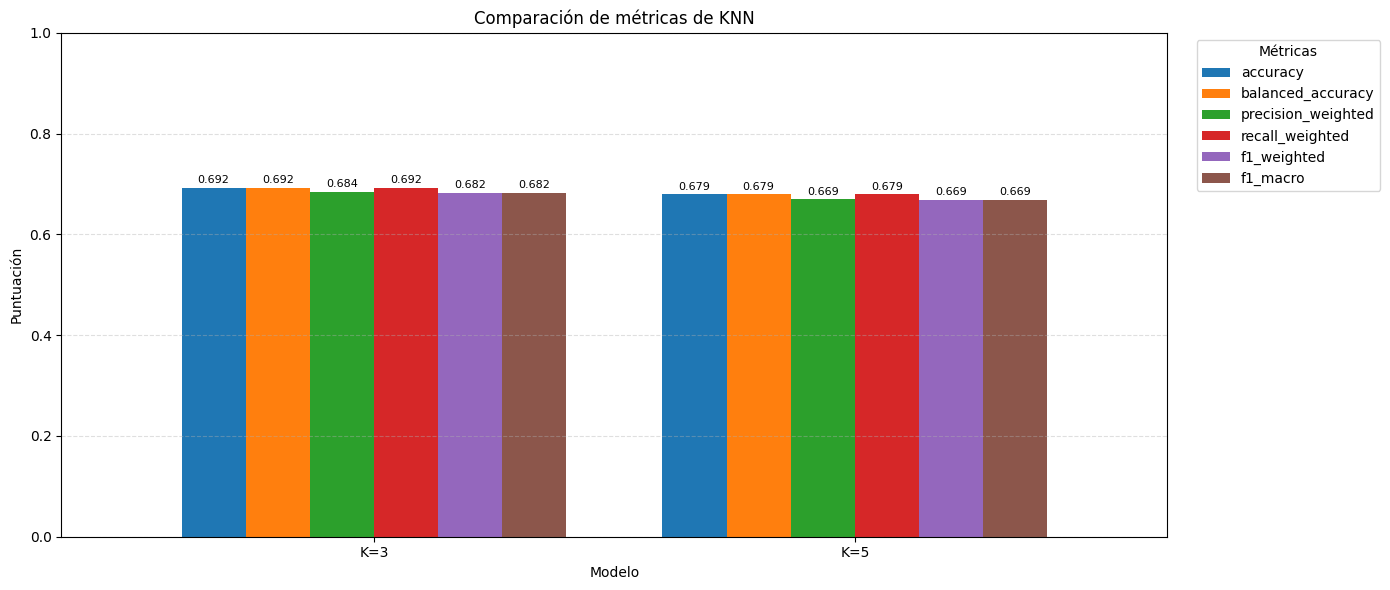

In [10]:
df_resultados_knn = pd.DataFrame({
    k: resultados_knn[k]["promedios"]
    for k in resultados_knn
}).T

df_resultados_knn.index = [
    f"K={k}" for k in df_resultados_knn.index
]

ax = df_resultados_knn.plot(
    kind="bar",
    figsize=(14, 6),
    width=0.8
)

plt.title("Comparación de métricas de KNN")
plt.xlabel("Modelo")
plt.ylabel("Puntuación")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Métricas", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(axis="y", linestyle="--", alpha=0.4)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8, padding=2)

plt.tight_layout()
plt.show()

In [11]:
mejor_k = max(
    resultados_knn,
    key=lambda k: resultados_knn[k]["promedios"]["f1_macro"]
)

print(f"Mejor valor de K: {mejor_k}")
print(
    f"F1-macro promedio: "
    f"{resultados_knn[mejor_k]['promedios']['f1_macro']:.4f}"
)

Mejor valor de K: 3
F1-macro promedio: 0.6818


In [13]:
knn_model = KNeighborsClassifier(
    n_neighbors=mejor_k,
    weights="uniform",
    metric="euclidean",
    n_jobs=-1
)

knn_model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",-1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](5,)","[0,1,2,3,4]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [14]:
y_pred_knn = knn_model.predict(X_test)

metricas_test_knn = {
    "accuracy": accuracy_score(y_test, y_pred_knn),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_knn),
    "precision_weighted": precision_score(
        y_test, y_pred_knn, average="weighted", zero_division=0
    ),
    "recall_weighted": recall_score(
        y_test, y_pred_knn, average="weighted", zero_division=0
    ),
    "f1_weighted": f1_score(
        y_test, y_pred_knn, average="weighted", zero_division=0
    ),
    "f1_macro": f1_score(
        y_test, y_pred_knn, average="macro", zero_division=0
    )
}

print("Resultados de KNN en el conjunto de prueba:")

for metrica, valor in metricas_test_knn.items():
    print(f"{metrica}: {valor:.4f}")

print("\nReporte de clasificación:")

print(
    classification_report(
        y_test,
        y_pred_knn,
        labels=knn_model.classes_,
        zero_division=0
    )
)

Resultados de KNN en el conjunto de prueba:
accuracy: 0.5310
balanced_accuracy: 0.5042
precision_weighted: 0.5534
recall_weighted: 0.5310
f1_weighted: 0.5353
f1_macro: 0.4515

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.60      0.67      0.63      6742
           1       0.57      0.49      0.53      6615
           2       0.59      0.45      0.51      6615
           3       0.32      0.48      0.38      2522
           4       0.13      0.43      0.20       191

    accuracy                           0.53     22685
   macro avg       0.44      0.50      0.45     22685
weighted avg       0.55      0.53      0.54     22685



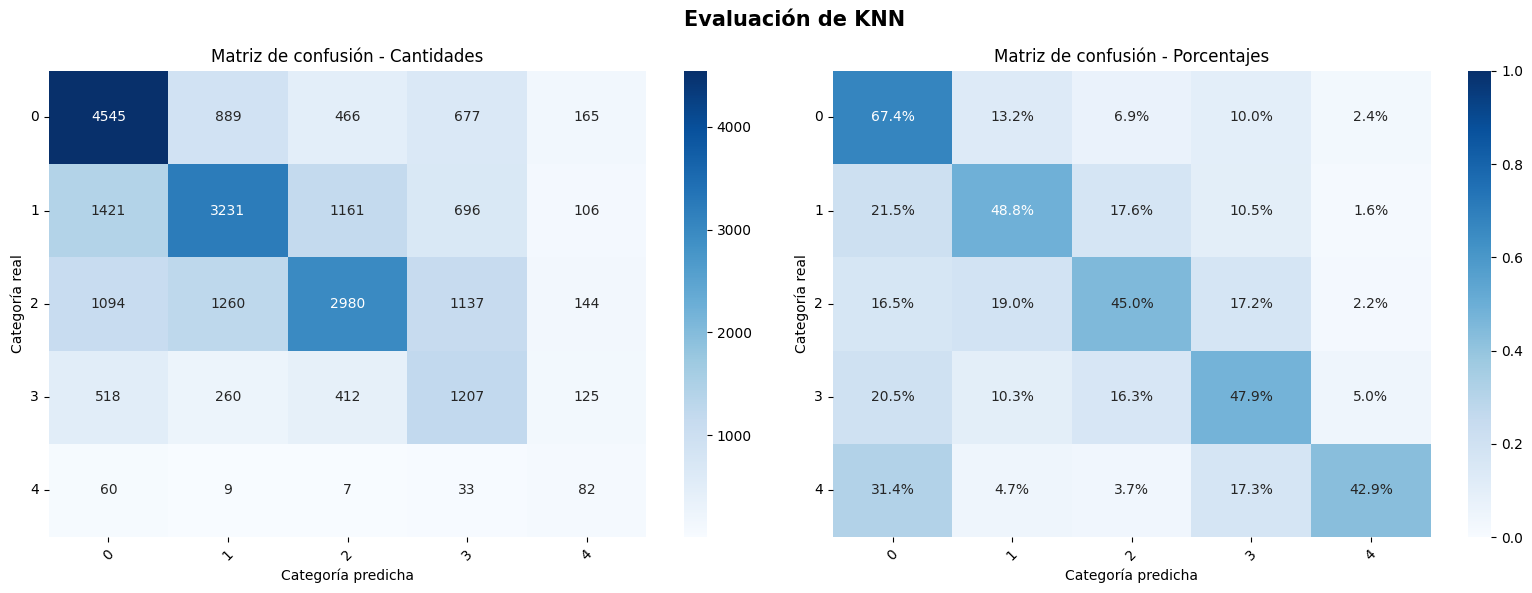

In [17]:
etiquetas = knn_model.classes_

matriz = confusion_matrix(
    y_test,
    y_pred_knn,
    labels=etiquetas
)

matriz_normalizada = confusion_matrix(
    y_test,
    y_pred_knn,
    labels=etiquetas,
    normalize="true"
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    matriz,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=etiquetas,
    yticklabels=etiquetas,
    ax=axes[0]
)

axes[0].set_title("Matriz de confusión - Cantidades")
axes[0].set_xlabel("Categoría predicha")
axes[0].set_ylabel("Categoría real")

sns.heatmap(
    matriz_normalizada,
    annot=True,
    fmt=".1%",
    cmap="Blues",
    vmin=0,
    vmax=1,
    xticklabels=etiquetas,
    yticklabels=etiquetas,
    ax=axes[1]
)

axes[1].set_title("Matriz de confusión - Porcentajes")
axes[1].set_xlabel("Categoría predicha")
axes[1].set_ylabel("Categoría real")

for ax in axes:
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

plt.suptitle(
    "Evaluación de KNN",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()